In [1]:
import pandas as pd
import numpy as np
import gower
import time
from sklearn_extra.cluster import KMedoids
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("../../data/processed/clean_dataset.csv")
display(df.head())
#nhóm các mức độ chấn thương
LOW  = ['NO INDICATION OF INJURY', 'REPORTED, NOT EVIDENT']
HIGH = ['NONINCAPACITATING INJURY', 'INCAPACITATING INJURY', 'FATAL']

def map_injury(x):
    if x in LOW:
        return 'LOW'
    elif x in HIGH:
        return 'HIGH'
    return 'UNKNOWN'
#tạo cột mới và tách dataframe
df['injury_level'] = df['most_severe_injury'].apply(map_injury)
df_low  = df[df['injury_level'] == 'LOW'].copy()
df_high = df[df['injury_level'] == 'HIGH'].copy()

print(df['injury_level'].value_counts())

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,29/07/2023 13:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,3,13,7,7
1,13/08/2023 0:11,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,2,0,1,8
2,09/12/2021 10:30,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,3,10,5,12
3,09/08/2023 19:55,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5,0,0,5,0,0,19,4,8
4,19/08/2023 14:55,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,3,14,7,8


injury_level
LOW     170840
HIGH     38435
Name: count, dtype: int64


In [3]:
features = [
    #môi trường
    'weather_condition','lighting_condition','roadway_surface_cond',
    #giao thông
    'trafficway_type','traffic_control_device', 
    #loại va chạm và nguyên nhân
    'first_crash_type','prim_contributory_cause',
    #thời gian
    'crash_hour','crash_day_of_week', 
    #quy mô va chạm
    'num_units'
]

num_cols = ['num_units', 'crash_hour', 'crash_day_of_week']

In [4]:
def stratified_sample(df, group_cols, n_total=5000, min_per_group=50, random_state=52):
    df = df.dropna(subset=group_cols)

    group_sizes = df.groupby(group_cols).size()
    proportions = group_sizes / group_sizes.sum()

    sample_sizes = (proportions * n_total).round().astype(int)

    sampled_df = []

    for group, size in sample_sizes.items():
        group_df = df.copy()

        for col, val in zip(group_cols, group if isinstance(group, tuple) else (group,)):
            group_df = group_df[group_df[col] == val]

        if len(group_df) == 0:
            continue

        size = max(size, min_per_group)
        size = min(size, len(group_df))

        sampled_df.append(
            group_df.sample(n=size, random_state=random_state)
        )

    return pd.concat(sampled_df).reset_index(drop=True)

In [ ]:
def compute_gower_and_tsne(df_sample):
    
    df_gower = df_sample.copy()
    
    # Ép kiểu cho cột numeric
    for col in num_cols:
        df_gower[col] = pd.to_numeric(df_gower[col], errors='coerce')
        
    # Xác định rõ cột nào là Categorical để tránh lỗi Numpy
    cat_features_bool = [col not in num_cols for col in features]

    # tính ma trận gower
    print("Đang tính toán Gower Matrix...")
    gower_dist = gower.gower_matrix(df_gower[features], cat_features=cat_features_bool)

    # t-SNE trực tiếp từ gower matrix
    print("Đang chạy t-SNE...")
    tsne = TSNE(
        n_components=2, 
        metric='precomputed',
        init='random',        
        perplexity=30, 
        random_state=42
    )
    X_tsne = tsne.fit_transform(gower_dist)

    return gower_dist, X_tsne

In [5]:
def preprocess(df_input):
    df_input = df_input.copy()
    df_input.columns = df_input.columns.str.lower()
    df_cluster = df_input[features].dropna().copy()

    # STRATIFIED SAMPLING
    df_sample = stratified_sample(
        df_cluster,
        group_cols=['weather_condition','lighting_condition'],
        n_total=5000,
        min_per_group=50,
        random_state=52
    )
    
    # Tính Gower và t-SNE
    gower_dist, X_tsne = compute_gower_and_tsne(df_sample)

    return df_sample, gower_dist, X_tsne 

In [7]:
def find_best_k(gower_dist, X_tsne, k_range=range(2,6)):
    sil_scores = []
    costs = []
    dbi_scores = []
    for k in k_range:
        model = KMedoids(
            n_clusters=k,
            metric='precomputed',
            method='pam',
            random_state=42
        )
        labels = model.fit_predict(gower_dist)
        # Silhouette
        sil = silhouette_score(gower_dist, labels, metric='precomputed')
        sil_scores.append(sil)
        # Cost
        cost = model.inertia_
        costs.append(cost)
        # DBI (trên embedding)
        dbi = davies_bouldin_score(X_tsne, labels)
        dbi_scores.append(dbi)
        print(f"K={k} | Sil={sil:.4f} | DBI={dbi:.4f} | Cost={cost:.4f}")
    # ===== Plot =====
    plt.figure(figsize=(15,4))
    plt.subplot(1,3,1)
    plt.plot(list(k_range), sil_scores, marker='o')
    plt.title("Silhouette")
    plt.subplot(1,3,2)
    plt.plot(list(k_range), dbi_scores, marker='o') 
    plt.title("DBI")
    plt.subplot(1,3,3)
    plt.plot(list(k_range), costs, marker='o')
    plt.title("Cost")
    plt.tight_layout()
    plt.show()

    scaler = MinMaxScaler()
    sil_norm = scaler.fit_transform(np.array(sil_scores).reshape(-1,1)).flatten()
    cost_norm = scaler.fit_transform(np.array(costs).reshape(-1,1)).flatten()
    dbi_norm = scaler.fit_transform(np.array(dbi_scores).reshape(-1,1)).flatten()

    combined = 1.5 * sil_norm - cost_norm - dbi_norm
    best_k = list(k_range)[np.argmax(combined)]
    print("\n K tốt nhất =", best_k)
    return best_k

In [8]:
def run_pam(df_sample, gower_dist, k, X_tsne, label_name):
    start_time = time.time()
    model = KMedoids(
        n_clusters=k,
        metric='precomputed',
        method='pam',
        random_state=42
    )
    labels = model.fit_predict(gower_dist)
    end_time = time.time()
    runtime = end_time - start_time
    df_sample = df_sample.copy()
    df_sample['cluster'] = labels

    # AFTER t-SNE
    plt.figure(figsize=(6,5))
    sns.scatterplot(
        x=X_tsne[:,0],
        y=X_tsne[:,1],
        hue=labels,
        palette='tab10'
    )
    plt.title(f"{label_name} - PAM")
    plt.show()

    # PROFILE
    def mode(x):
        return x.value_counts().index[0]

    profile = df_sample.groupby('cluster')[features].agg(mode)

    print(f"\n[{label_name}] Cluster Profile:")
    display(profile)
    print(f"\n PAM runtime ({label_name}): {runtime:.2f} seconds")
    return df_sample

Đang tính toán Gower Matrix...
Đang chạy t-SNE...
K=2 | Sil=0.1000 | DBI=2.2343 | Cost=2418.1692
K=3 | Sil=0.0885 | DBI=2.4904 | Cost=2249.8699
K=4 | Sil=0.0928 | DBI=1.6348 | Cost=2112.7068
K=5 | Sil=0.0913 | DBI=2.0383 | Cost=2036.2612


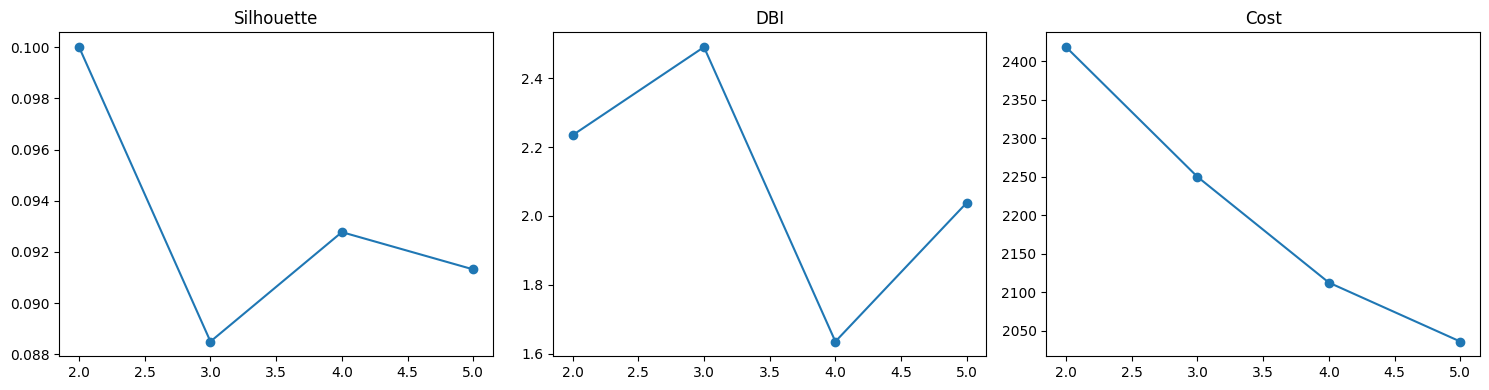


 K tốt nhất = 4


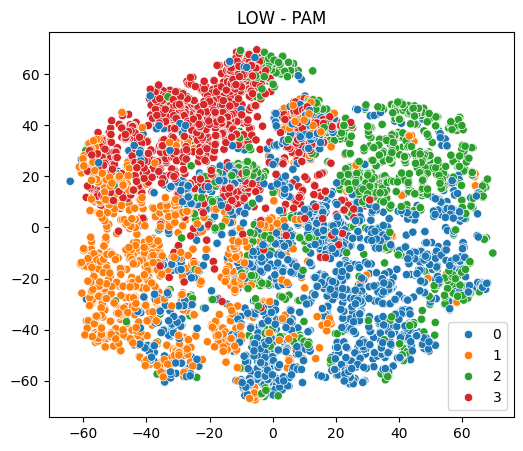


[LOW] Cluster Profile:


,weather_condition,lighting_condition,roadway_surface_cond,trafficway_type,traffic_control_device,first_crash_type,prim_contributory_cause,crash_hour,crash_day_of_week,num_units
cluster,,,,,,,,,,
0,CLEAR,DAYLIGHT,DRY,NOT DIVIDED,TRAFFIC SIGNAL,TURNING,UNKNOWN,16,6,2
1,CLEAR,DAYLIGHT,DRY,FOUR WAY,STOP SIGN/FLASHER,ANGLE,FAILING TO YIELD RIGHT-OF-WAY,15,4,2
2,CLEAR,DAYLIGHT,DRY,DIVIDED - W/MEDIAN (NOT RAISED),TRAFFIC SIGNAL,REAR END,FOLLOWING TOO CLOSELY,17,3,2
3,RAIN,"DARKNESS, LIGHTED ROAD",WET,NOT DIVIDED,TRAFFIC SIGNAL,TURNING,UNKNOWN,17,2,2



 PAM runtime (LOW): 13.81 seconds


In [9]:
df_sample_low, gower_low, X_tsne_low = preprocess(df_low)
k_low = find_best_k(gower_low, X_tsne_low)
df_low_cluster = run_pam(df_sample_low, gower_low, k_low, X_tsne_low, "LOW")

Đang tính toán Gower Matrix...
Đang chạy t-SNE...
K=2 | Sil=0.1025 | DBI=3.7076 | Cost=2122.3726
K=3 | Sil=0.1147 | DBI=2.3989 | Cost=1982.4402
K=4 | Sil=0.1020 | DBI=1.5365 | Cost=1833.3951
K=5 | Sil=0.0831 | DBI=2.1514 | Cost=1766.7850


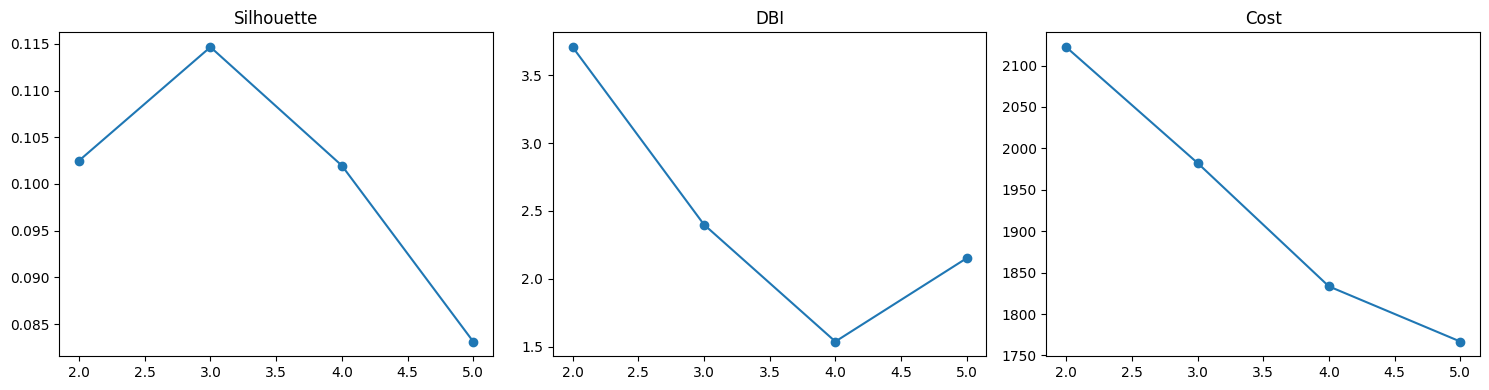


 K tốt nhất = 4


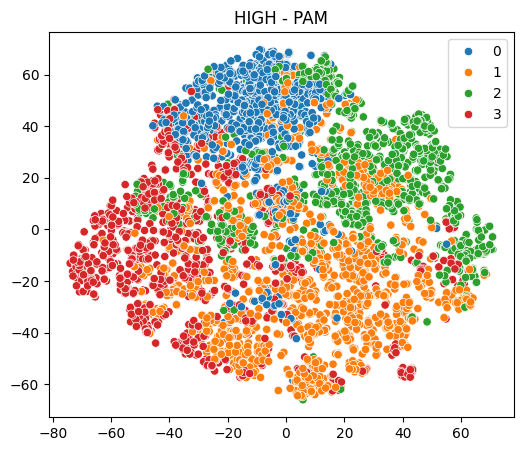


[HIGH] Cluster Profile:


,weather_condition,lighting_condition,roadway_surface_cond,trafficway_type,traffic_control_device,first_crash_type,prim_contributory_cause,crash_hour,crash_day_of_week,num_units
cluster,,,,,,,,,,
0,RAIN,DAYLIGHT,WET,NOT DIVIDED,TRAFFIC SIGNAL,PEDESTRIAN,FAILING TO YIELD RIGHT-OF-WAY,18,6,2
1,CLEAR,DAYLIGHT,DRY,NOT DIVIDED,TRAFFIC SIGNAL,TURNING,UNKNOWN,14,4,2
2,CLEAR,"DARKNESS, LIGHTED ROAD",DRY,FOUR WAY,TRAFFIC SIGNAL,ANGLE,DISREGARDING TRAFFIC SIGNALS,22,1,2
3,CLEAR,DAYLIGHT,DRY,FOUR WAY,STOP SIGN/FLASHER,ANGLE,FAILING TO YIELD RIGHT-OF-WAY,17,7,2



 PAM runtime (HIGH): 12.30 seconds


In [10]:
df_sample_high, gower_high, X_tsne_high = preprocess(df_high)
k_high = find_best_k(gower_high, X_tsne_high)
df_high_cluster = run_pam(df_sample_high, gower_high, k_high, X_tsne_high, "HIGH")